# Figure 4
In this notebook we load and ploat data that was used to generate Figure 4.

In [6]:
from pathlib import Path
from types import SimpleNamespace
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker 
import numpy as np
import pickle

np.set_printoptions(precision=5, suppress=True) 

In [2]:
from matplotlib.colors import to_rgb

def set_rcparams():
    from matplotlib import rcParams
    rcParams['figure.figsize'] = 3.375, 2 # PRX single-column width is 3+3/8 inches
    rcParams['lines.linewidth'] = 1 # PRX minimum is 0.5 point, and a point is always 1/72 inch.
    rcParams['lines.markersize'] = 6 # PRX minimum for diameter of datapoint is 1mm (2.83 point)
    rcParams['text.usetex'] = True
    rcParams['font.family'] = 'serif'
    rcParams['font.size'] = 10 # revtex default is 10 pt for 'twocolumn'
set_rcparams()

Let's define a few useful functions

In [3]:
def plot_dataset(d, errorbars=False, 
                 fig_ax=None, 
                 f=lambda x: x, # filter function
                 show_data=True,
                 label_post=r'',
                 show_title=True,
                 figsize=None,
                 color=None,
                 linestyle=None,
                 linewidth=1,
                ):
    # print(f"x_l_uncor {d.x_l_uncor}")
    # print(f"x_l       {f(d.x_l)}") 
    
    samples=d.params.samples * d.data_files_count
    
    if fig_ax is not None:
        fig, axes = fig_ax
    else:
        fig, axes = plt.subplots(2, 1, figsize=figsize, dpi=300, sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})
    
    x=f(np.arange(d.x_l.size)) 
    x_l=f(d.x_l)
    x_l_var=f(d.x_l_var)

    if show_data:
        if errorbars:
            axes[0].errorbar(x/2, x_l, yerr=np.sqrt(x_l_var)/np.sqrt(samples), 
                        label=label_post, 
                        # marker="o", 
                        markersize=4,
                        capsize=1,
                        zorder=0,
                        color=color,
                        linestyle=linestyle,
                        linewidth=linewidth,
                       )
        else:
            axes[0].plot(x/2, x_l, 
                    label=label_post, 
                    #marker="o",
                    markersize=4,
                    zorder=0,
                    color=color,
                    linestyle=linestyle,
                    linewidth=linewidth,
                    )
        
    if show_title:
        axes[0].set_title(f"theta={d.params.theta/(np.pi)}*pi, errors={d.params.errors}, random_zs={d.params.random_zs}")
        # , random_zs={d.params.random_zs}")
        
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    axes[0].set_xlim(0, max(x/2))
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel(r"Corrected $\langle\overline{X}\rangle$")
    # axes[0].set_ylabel("expectation value")
    # axes[0].legend()
    
    axes[1].set_xlabel(r"Number of foliation rounds $L$")
    return fig, axes


def plot_discrepancy(d1, d2, fig_ax, 
                 f=lambda x: x, # filter function
                 color=None,
                 linestyle=None,
                 linewidth=1,
                 vertical_offset=0,
                ):
    # print(f"x_l_uncor {d.x_l_uncor}")
    # print(f"x_l       {f(d.x_l)}") 
    
    samples1=d1.params.samples * d1.data_files_count
    samples2=d2.params.samples * d2.data_files_count
    
    fig, axes = fig_ax
    
    x1=f(np.arange(d1.x_l.size)) 
    x_l1=f(d1.x_l)
    x_l_var1=f(d1.x_l_var)

    x2=f(np.arange(d2.x_l.size)) 
    x_l2=f(d2.x_l)
    x_l_var2=f(d2.x_l_var)

    var_diff = (np.sqrt(x_l_var1)/np.sqrt(samples1))**2 + (np.sqrt(x_l_var2)/np.sqrt(samples2))**2
    scale = 1 / (1.96 * np.sqrt(var_diff)[-1])

    axes[1].plot(x1/2, np.zeros_like(x1/2) + vertical_offset, color='k', linewidth=0.5 * linewidth, zorder=-1)
    axes[1].plot(x1/2, scale * (x_l2 - x_l1) + vertical_offset,
            color=color,
            linewidth=linewidth,
            linestyle=linestyle,
            )
    axes[1].fill_between(x1/2,
                         scale * (x_l2 - x_l1 - 1.96 * np.sqrt(var_diff)) + vertical_offset,
                         scale * (x_l2 - x_l1 + 1.96 * np.sqrt(var_diff)) + vertical_offset, 
            color=(to_rgb(color) + np.array([1,1,1])) / 2,
            alpha=0.75,
            linewidth=0,
            zorder=0,
            )
        
    axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    axes[1].set_xlim(0, max(x1/2))
    
    # clear y major ticks
    axes[1].set_yticks([])
    # fclear y minor ticks
    axes[1].set_yticks([], minor=True)
    axes[1].set_ylabel('Diff.')
    
    return fig, axes

## load the data sets and plot

In [4]:
def combine_sample_statistics(
    means: np.ndarray,
    sample_variances: np.ndarray,
    counts,  # Updated type hint
) -> tuple[np.ndarray, np.ndarray]:
    """
    Combine M per-dataset summary stats (means, sample variances, counts)
    into a single combined mean and an ***unbiased*** estimate of the 
    population variance (i.e., the combined sample variance).

    This function assumes that the individual sample_variances were calculated
    using a denominator of (N_j - 1).

    Parameters
    ----------
        means: numpy.ndarray of shape (M, D), representing M dataset means,
               each for a D-dimensional variable. Each mean mu_j is calculated
               over N_j samples.
        sample_variances: numpy.ndarray of shape (M, D), representing M dataset
                          sample variances (s_j^2). Each s_j^2 is assumed to be
                          calculated with a denominator of (N_j - 1).
                          If N_j=1 for a particular dataset, its s_j^2 is
                          conventionally 0.
        counts: Union[numpy.ndarray, int, float].
                If numpy.ndarray (or array-like, e.g., list): shape (M,),
                                     representing the N_j sample counts for each
                                     dataset. Each N_j must be an integer >= 1.
                If int or float: A single number N0, representing the common
                                 number of samples for all M datasets. N0 must
                                 be an integer >= 1 (e.g., 5 or 5.0).

    Returns
    -------
        mean_combined: numpy.ndarray of shape (D,), the combined (weighted) mean.
        var_combined: numpy.ndarray of shape (D,), the combined sample variance.
                      This is calculated with a denominator of (N_tot - 1).
                      Returns np.nan if M=0 (no datasets).
                      Returns 0.0 if N_tot = 1.


    TODO:
        - support unbiased/biased averaging; currently assume data
          obtained using unbiased=True

    """
    means_arr = np.asarray(means)
    variances_arr = np.asarray(sample_variances)
    # counts_arr will be defined based on 'counts' input below

    if means_arr.ndim != 2:
        raise ValueError(
            f"means must be a 2D array (M, D), got {means_arr.ndim}D shape {means_arr.shape}"
        )
    M, D = means_arr.shape

    # print(f"means_arr {means_arr}")

    # Process 'counts' argument
    if isinstance(
        counts, (int, float, np.integer, np.floating)
    ):  # Check for scalar numeric types
        common_N0 = float(counts)  # Ensure it's float for np.full and consistent typing
        if common_N0 < 1:
            raise ValueError(
                "If counts is a single number N0 (common sample size), it must be >= 1."
            )
        if common_N0 != round(common_N0):  # Check if it represents an integer
            raise ValueError(
                "If counts is a single number N0, it must represent an integer count (e.g., 5.0, not 5.5)."
            )
        counts_arr = np.full(M, common_N0, dtype=float)
    else:
        # Assume counts is array-like (e.g., list, tuple, np.ndarray)
        try:
            counts_arr = np.asarray(counts, dtype=float)
        except (TypeError, ValueError) as e:  # Catch errors if 'counts' is unsuitable
            raise TypeError(
                f"counts must be a number or an array-like structure convertible to a numeric numpy array. Got type {type(counts)}."
            ) from e

        if counts_arr.ndim != 1 or counts_arr.shape[0] != M:
            raise ValueError(
                f"If counts is an array-like structure, it must be 1D with shape ({M},) "
                f"to match the number of datasets ({M}) inferred from means. Got shape {counts_arr.shape}."
            )

    # General validations for derived counts_arr and other inputs
    if variances_arr.shape != (M, D):
        raise ValueError(
            f"sample_variances shape {variances_arr.shape} must match means shape {(M, D)}"
        )

    if M > 0:  # Only validate content if there are datasets/counts to check
        if np.any(counts_arr < 1):
            raise ValueError(
                "All N_j values (elements of counts or the common N0) must be >= 1."
            )
        if np.any(
            counts_arr != np.round(counts_arr)
        ):  # Ensure all counts are whole numbers
            raise ValueError("All N_j values in counts must represent integers.")

    # Handle M=0 case (no datasets provided)
    if M == 0:
        # D could be 0 if input means_arr was shape (0,0). np.full will handle D=0.
        return np.full(D, np.nan, dtype=float), np.full(D, np.nan, dtype=float)

    N_tot = np.sum(counts_arr)
    # Given M > 0 and validated counts_arr elements (integers >= 1), N_tot will be >= M >= 1.

    # Combined mean
    mean_combined = np.average(means_arr, axis=0, weights=counts_arr)

    # Sum of Squares Within (SS_within) = sum_{j} (N_j - 1) * s_j^2
    degrees_of_freedom_j = counts_arr - 1
    SS_within_terms = degrees_of_freedom_j[:, np.newaxis] * variances_arr
    SS_within = np.sum(SS_within_terms, axis=0)

    # Sum of Squares Between (SS_between) = sum_{j} N_j * (mu_j - mu_combined)^2
    diff_means_sq = (means_arr - mean_combined[np.newaxis, :]) ** 2
    SS_between_terms = counts_arr[:, np.newaxis] * diff_means_sq
    SS_between = np.sum(SS_between_terms, axis=0)

    SS_total = SS_within + SS_between

    # Combined sample variance s_combined^2 = SS_total / (N_tot - 1)
    if N_tot == 1:
        # If N_tot is 1 (e.g., M=1 and N_1=1), sample variance is 0.
        # SS_total will also be 0 in this scenario.
        var_combined = np.zeros(D, dtype=float)
    else:  # N_tot > 1 (N_tot cannot be < 1 if M > 0 due to N_j >= 1 check)
        var_combined = SS_total / (N_tot - 1)

    return mean_combined, var_combined

def load_data(file_name: str | Path = "."):
    """
    Load data from a given path
    """
    file_name = Path(file_name)

    if not file_name.is_file():
        raise FileNotFoundError(f"File {file_name} not found")

    with file_name.open("rb") as fh:
        d = pickle.load(fh)

    return d


def find_files(
    patterns,
    folder: str | Path = ".",
    recursive: bool = False,
    patterns_either: None = None,
    patterns_skip: list[str] | None = None,
):
    """
    Return every file under `folder` whose **basename** contains *all* of the
    supplied patterns, regardless of order.

    Parameters
    ----------
    patterns: Iterable[str]
        Sub-strings that must ALL appear somewhere in the filename
        (case-insensitive).
    folder: str | Path, optional
        Directory to search (default: current working directory).
    recursive: bool, optional
        If True search recursively with '**/*'. If False, look only
        in *folder*.
    patterns_either: Iterable[str] | None, optional
        Sub-strings where AT LEAST ONE must appear in the filename
        (case-insensitive). If None or empty, this filter is skipped.
    patterns_skip: list[str] | None, optional
        Sub-strings where if ANY appear in the filename, the file is
        excluded (case-insensitive). If None or empty, this filter is skipped.

    Returns
    -------
    list[pathlib.Path]
        Paths that satisfy the test, sorted lexicographically.
    """
    folder = Path(folder)
    if not folder.is_dir():
        raise RuntimeError(f"folder {folder} does not exist")

    patterns = [p.lower() for p in patterns]
    patterns_either_lower = [p.lower() for p in patterns_either] if patterns_either else []
    patterns_skip_lower = [p.lower() for p in patterns_skip] if patterns_skip else []

    glob_pat = "**/*" if recursive else "*"
    matches: list[Path] = []

    for path in folder.glob(glob_pat):
        if not path.is_file():
            continue
        name = path.name.lower()

        # ALL of `patterns` must match
        if not all(p in name for p in patterns):
            continue

        # AT LEAST ONE of `patterns_either` must match (if provided)
        if patterns_either_lower and not any(p in name for p in patterns_either_lower):
            continue

        # NONE of `patterns_skip` should match
        if patterns_skip_lower and any(p in name for p in patterns_skip_lower):
            continue

        matches.append(path)

    return sorted(matches)


def load_dataset(
    params: SimpleNamespace,
    data_dir: str | Path,
    labels,
    recursive: bool = False,
    extra_patterns: list[str] = None,
    patterns_either: list[str] | None = None,
    patterns_skip: list[str] | None = None,
):
    """
    Load data from all the data files in a given data_dir, and combine means and variances.
    """
    # Construct the mandatory patterns from params
    patterns = [f"{key}_{value}-" for key, value in vars(params).items()]
    if extra_patterns is not None:
        patterns += extra_patterns

    file_names = find_files(
        patterns,
        data_dir,
        recursive=recursive,
        patterns_either=patterns_either,
        patterns_skip=patterns_skip,
    )
    data_files_count = len(file_names)
    if data_files_count < 1:
        raise ValueError(f"No data files were found")

    data = list(map(load_data, file_names))

    d = SimpleNamespace(
        params=params,
        patterns=patterns,
        patterns_either=patterns_either,
        patterns_skip=patterns_skip,
        data_files_count=data_files_count,
    )

    for i, name in enumerate(labels):
        means = np.stack([getattr(item, name) for item in data], axis=0)
        variances = np.stack([getattr(item, name + "_var") for item in data], axis=0)
        m, v = combine_sample_statistics(
            means=means,
            sample_variances=variances,
            counts=params.samples,
        )
        setattr(d, name, m)
        setattr(d, name + "_var", v)

    print(f"Loaded a dataset from {data_files_count} data files.")
    return d



def make_plot():
    data={}

    labels_and_thetas = [
                        ('0.01pi', 0.01*np.pi), 
                        ('0.015pi', 0.015*np.pi),
                        ('0.02pi', 0.02*np.pi)
        ]
    colors = ["#1D7091", "#2EA560", "#D0BE22"]

    for label, theta in labels_and_thetas:
        for sim_type in [
            'coherent', 
            'stochastic'
        ]:
            print(f"processing {label}, {theta}, {sim_type}")
            data[f"{label}_{sim_type}"] = load_dataset(SimpleNamespace(samples=100, 
                                                                        cycles=200, 
                                                                        theta=theta, 
                                                                        random_zs='random' if sim_type=='coherent' else 'zeros',
                                                                        errors=f'z_{sim_type}'),
                                                        data_dir=f"./data/ancilla_errors_ideal_readout_{sim_type}_long2",
                                                        labels=['x_l'], 
                                                        )
    fig_ax = None
    for (label, theta), color in zip(labels_and_thetas, colors):
        for sim_type in [
            'coherent', 
            'stochastic'
        ]:
            fig_ax = plot_dataset(data[f"{label}_{sim_type}"], 
                        errorbars=False, 
                        # f=lambda x: x[1::2],  #odd
                        f=lambda x: x[::2],  #even
                        # f=lambda x: x[170:],
                        show_data=True,
                        show_title=False,
                        label_post=f" ({label})",
                        figsize=(3+3/8,2.5),
                        fig_ax=fig_ax,
                        color='k' if sim_type == 'coherent' else color,
                        linestyle='-' if sim_type == 'coherent' else '--',
                        linewidth=1 if sim_type == 'coherent' else 2,
                        )

    for ind, ((label, theta), color) in enumerate(zip(labels_and_thetas, colors)):
        fig_ax = plot_discrepancy(data[label+'_coherent'], data[label+'_stochastic'],
                f=lambda x: x[::2],  #even
                fig_ax=fig_ax,
                color=color,
                linestyle='--',
                linewidth=1,
                vertical_offset=-4*ind
                )
    
    fig, axes = fig_ax
    fig.subplots_adjust(left=0.18, right=0.98, top=0.97, bottom=0.16, hspace=0.1)
    fig.savefig("full_circuit_model.pdf")

processing 0.01pi, 0.031415926535897934, coherent
Loaded a dataset from 1555 data files.
processing 0.01pi, 0.031415926535897934, stochastic
Loaded a dataset from 1558 data files.
processing 0.015pi, 0.047123889803846894, coherent
Loaded a dataset from 892 data files.
processing 0.015pi, 0.047123889803846894, stochastic
Loaded a dataset from 820 data files.
processing 0.02pi, 0.06283185307179587, coherent
Loaded a dataset from 912 data files.
processing 0.02pi, 0.06283185307179587, stochastic
Loaded a dataset from 806 data files.


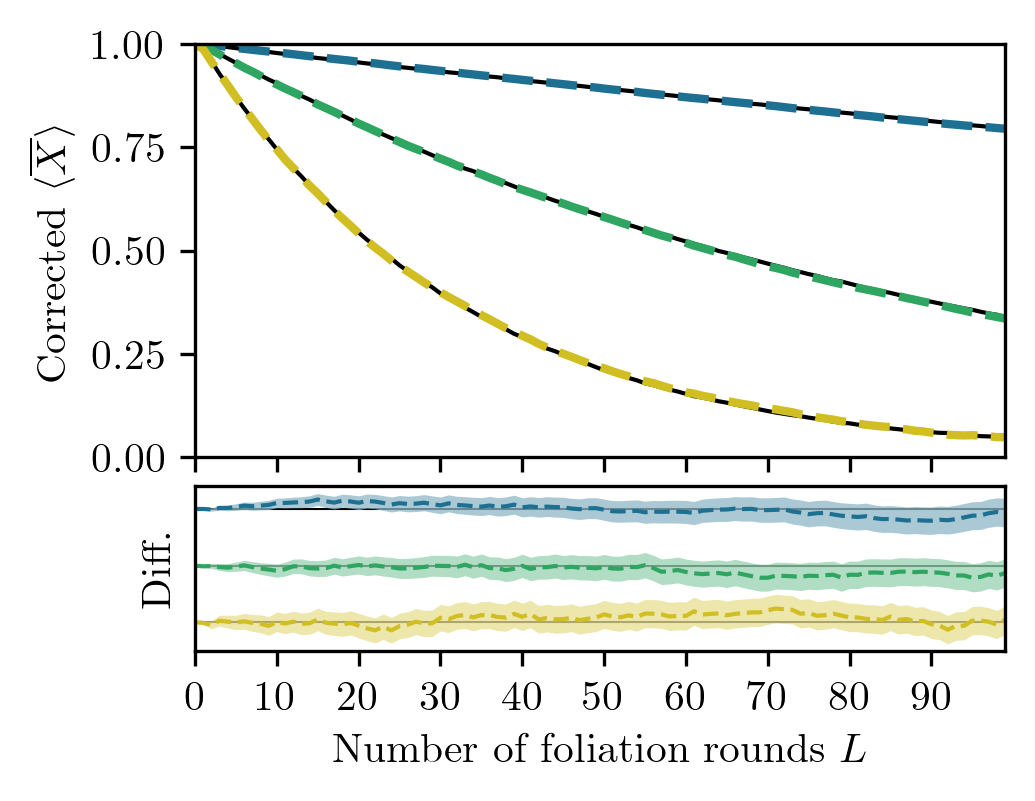

In [5]:
make_plot()